# DQN baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import DQN_QNetwork
from exploration.multi_agent_exploration import MultiAgentExplorer, IdentityEncoder

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env

BUFFER_CAPACITY=100000
GOAL=(9, 9)
LR= float(1e-3)

env = make_env(goal=GOAL)


## Multi-Agent explorer setup

In [3]:
explorer = MultiAgentExplorer.from_env(
    env_fn=lambda: make_env(goal=GOAL),
    num_agents=20,
    encoder=IdentityEncoder(),
    goal_extractor=lambda env: np.asarray(GOAL, dtype=np.float32),
    planner_overrides={
        "num_candidates": 16,

        # old motion-style terms
        "home_weight": 0.1,
        "memory_weight": 0.1,
        "repel_weight": 0.0,
        "memory_smooth": 0.5,

        # new S x A coverage terms
        "bin_size": 1.0,
        "action_bins": 4,
        "state_novelty_weight": 0.0,
        "state_action_novelty_weight": 1.0,
        "transition_novelty_weight": 0.5,

        # optional directed-to-goal bias
        "goal_weight": 0.5,

        # search behavior
        "step_size": 0.5,
        "jitter_scale": 0.05,
        "count_eps": 1.0,
    },
    seed=0,
)

[step=20] time_elapsed_for_data_collection=0.00854 s
[step=40] time_elapsed_for_data_collection=0.00874 s
[step=60] time_elapsed_for_data_collection=0.00806 s
[step=80] time_elapsed_for_data_collection=0.00842 s
[step=100] time_elapsed_for_data_collection=0.00818 s
[step=120] time_elapsed_for_data_collection=0.00825 s
[step=140] time_elapsed_for_data_collection=0.00815 s
[step=160] time_elapsed_for_data_collection=0.00832 s
[step=180] time_elapsed_for_data_collection=0.00805 s
[step=200] time_elapsed_for_data_collection=0.00813 s
[step=220] time_elapsed_for_data_collection=0.00798 s
[step=240] time_elapsed_for_data_collection=0.00834 s
[step=260] time_elapsed_for_data_collection=0.00815 s
[step=280] time_elapsed_for_data_collection=0.00810 s
[step=300] time_elapsed_for_data_collection=0.00781 s
[step=320] time_elapsed_for_data_collection=0.00806 s
[step=340] time_elapsed_for_data_collection=0.00805 s
[step=360] time_elapsed_for_data_collection=0.00799 s
[step=380] time_elapsed_for_data

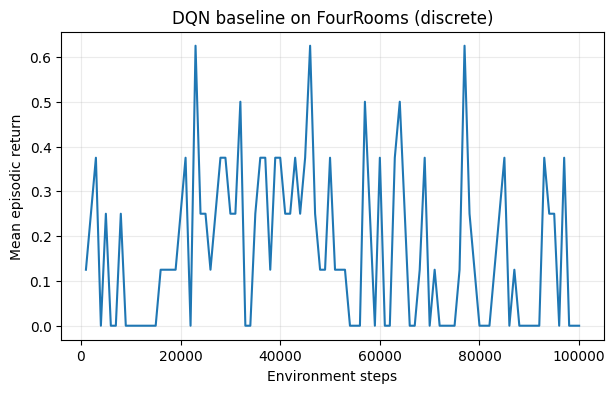

In [4]:

obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n

q_net = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)



def multi_agent_dqn_train(q_network=q_net, q_target_network=q_target, env=env, buffer_capacity=BUFFER_CAPACITY, lr=LR, obs_dim=obs_dim, device=DEVICE,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    train_freq=4,
    goal=GOAL,
    params= q_net.parameters(),
    eval_every=1000,
    multi_agent_explorer=explorer,
):
    
    opt = optim.Adam(params, lr=lr)
    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    multi_agent_explorer.reset()    
    global_step = 0
    eval_returns = []

    wall_clock_start = time.perf_counter()

    while global_step < total_steps:
        stats = multi_agent_explorer.collect_steps(
        replay_buffer=buffer,
        num_steps=1,                 # one synchronized step for each agent
        flush_partial_episodes=False
        )
        global_step += stats["num_transitions"]
        time_elapsed = time.perf_counter() - wall_clock_start
        print(f"[step={global_step}] time_elapsed_for_data_collection={time_elapsed:.5f} s")
        wall_clock_start = time.perf_counter()

        # Training update
        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()  # cast to int64 for use as gather indices
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated

            with torch.no_grad():
                next_q = q_target_network(next_obs_t).max(dim=-1, keepdim=True).values
                target = rew_t + gamma * (1.0 - term_t) * next_q

            current_q = q_network(obs_t).gather(1, act_t.unsqueeze(1))
            loss = F.mse_loss(current_q, target)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            opt.step()

            # Soft update target network
            for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % eval_every == 0:
            eval_env = make_env(goal)
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: int(
                    q_network(
                        torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                    ).argmax(dim=-1).item()
                ),
                episodes=8,
            )
            eval_returns.append((global_step, mean_ret))
            print(f'[DQN] step={global_step:7d} | eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}')
            eval_env.close()

    env.close()

    wall_clock_end = time.perf_counter()
    total_elapsed = wall_clock_end - wall_clock_start
    print(f"Total training wall-clock time: {total_elapsed:.1f} s")

    return q_network, eval_returns

dqn_q_first, dqn_eval_first = multi_agent_dqn_train()

if dqn_eval_first:
    xs, ys = zip(*dqn_eval_first)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('DQN baseline on FourRooms (discrete)')
    plt.grid(alpha=0.25)
    plt.show()


## Visualisations

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 7 steps | return: 1.00 | reached goal: True
Episode 4: 8 steps | return: 1.00 | reached goal: True
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 25.00% over 8 episodes
Average return: 0.25 ± 0.43


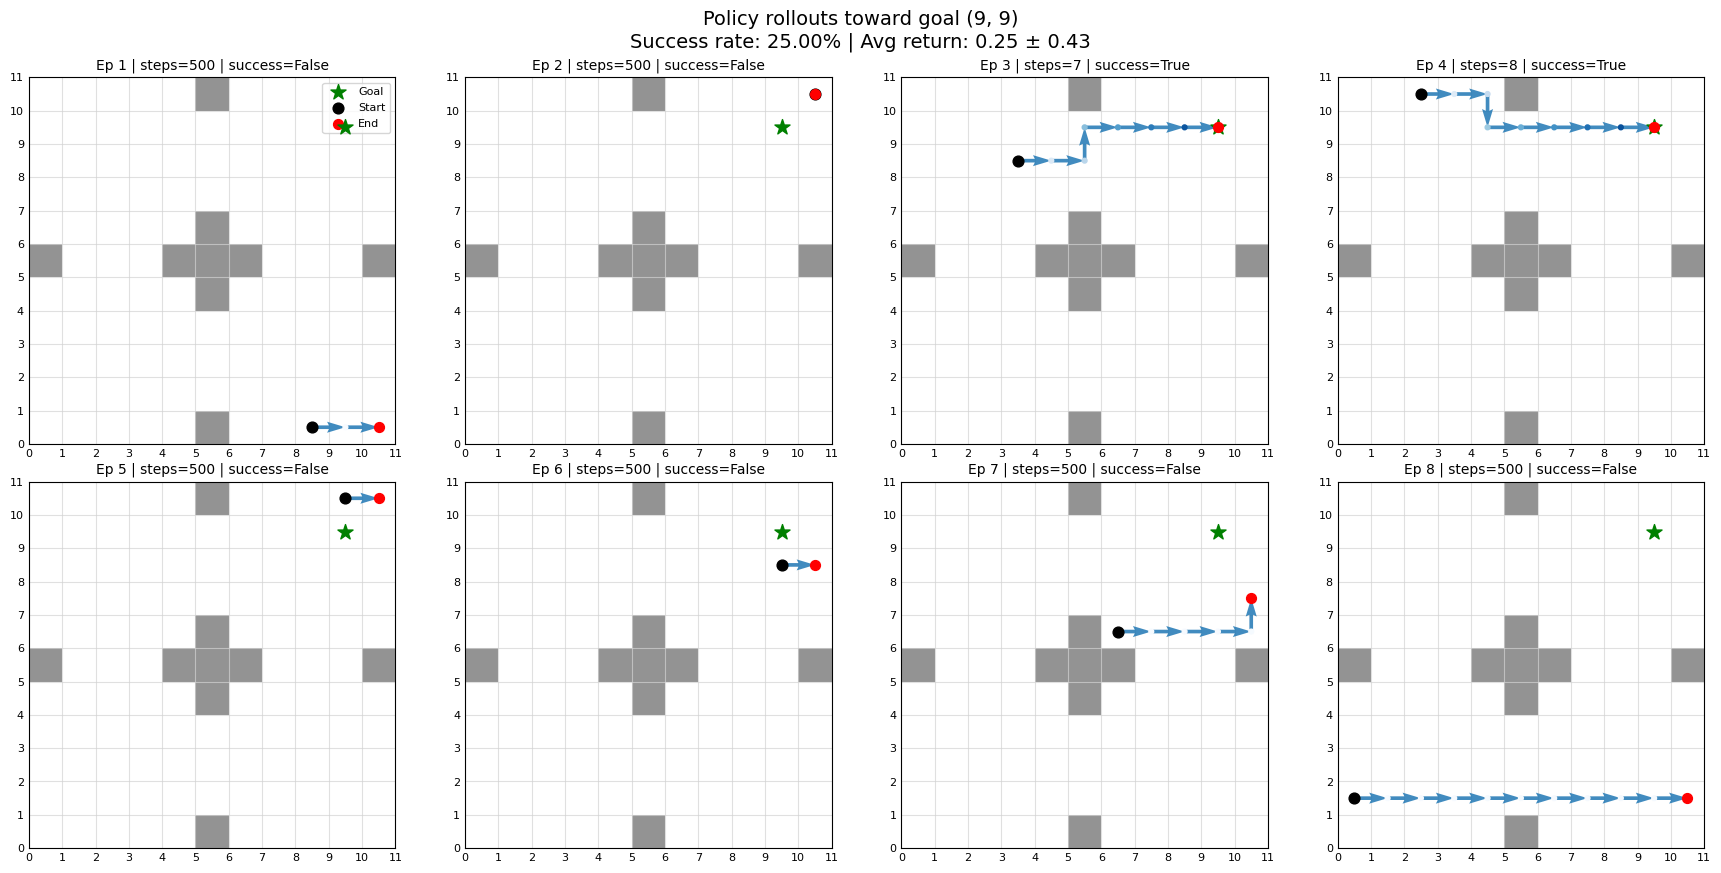

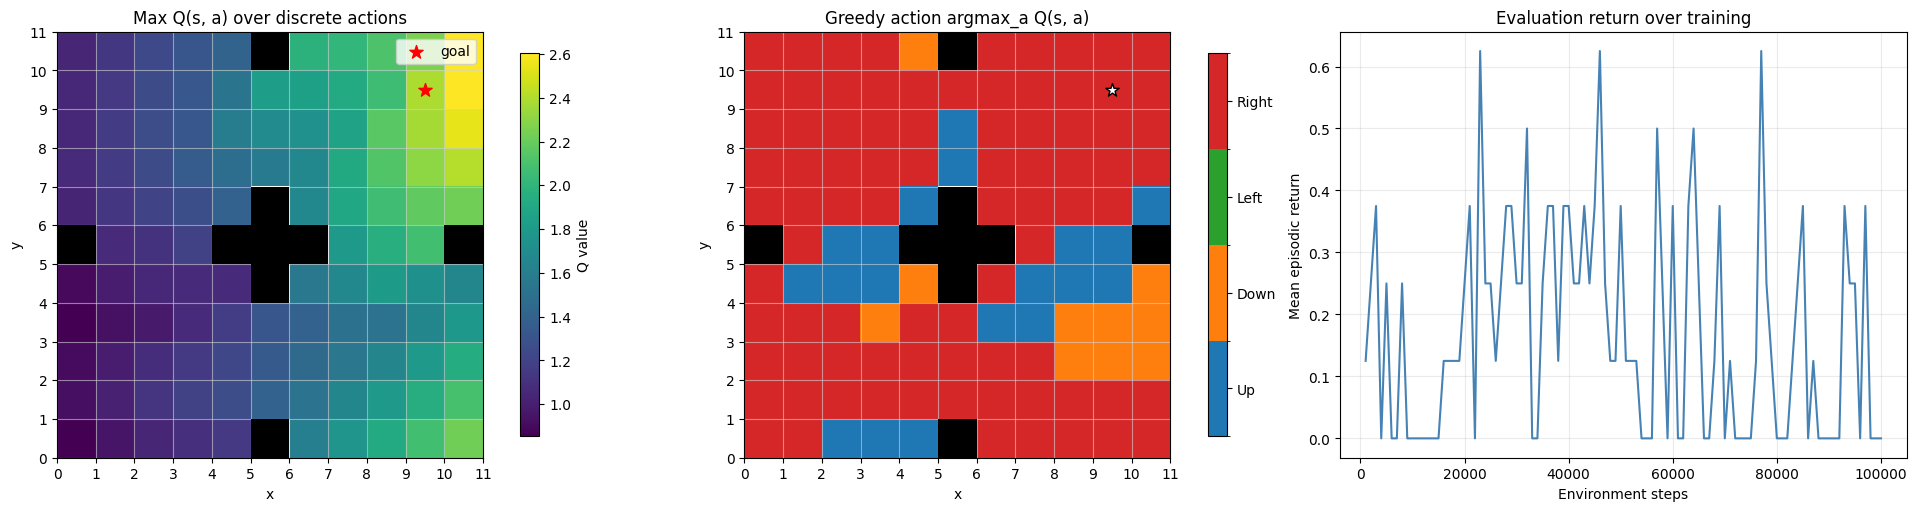

DQN_QNetwork(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [5]:

dqn_q_first.eval()
eval_env_first = make_env(goal=(9, 9))


def dqn_policy_fn(obs,q_network):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        action = int(q_network(obs_t).argmax(dim=-1).item())
    return action


def dqn_value_fn(obs_batch, q_network):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        q_vals = q_network(obs_t).cpu().numpy()
    return q_vals


plot_policy_rollouts(
    env=eval_env_first,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_first),
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env_first.close()

eval_env_first = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env_first,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_first),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=(9, 9),
    eval_returns=dqn_eval_first,
)

eval_env_first.close()

dqn_q_first.train()


## Now to check how much samples needed to reach a new goal